In [86]:
import shutil
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from collections import Counter
import os
from struct_eval_functions import *
from struct_plot_funcitons import *

### JSON to Text

In [87]:
def process_node(node):
    if 'raw_text' in node:
        return node['raw_text'].strip()
    if 'AND' in node:
        left_text = process_node(node['AND']['left'])
        right_text = process_node(node['AND']['right'])
        return combine_texts(left_text, right_text, '[AND]')
    if 'OR' in node:
        left_text = process_node(node['OR']['left'])
        right_text = process_node(node['OR']['right'])
        return combine_texts(left_text, right_text, '[OR]')
    if 'NOT' in node:
        left_text = process_node(node['NOT']['left'])
        return f"[NOT] {left_text}"

    return ""

def combine_texts(left_text, right_text, operator):
    ### Hier muss es bearbeitet werden Entweder lösche AND am ENDE oder nicht
    #if operator == '[AND]' and (left_text.strip().endswith('.') or right_text.strip().startswith('-')):
    #    return f"{left_text}\n{right_text}"
    combined = f"{left_text.strip()} {operator} {right_text.strip()}"
    if operator == '[AND]' and not right_text.strip():
        return combined + '\n'
    return combined


def json_to_text(json_file_path):
    with open(json_file_path, 'r', encoding="utf-8") as f:
        data = json.load(f)
    text = process_node(data)
    lines = [line.strip() for line in text.split('\n') if line.strip()]
    return '\n'.join(lines)

def process_all_files_in_directory(directory_path, output_directory, failure_directory):
    os.makedirs(output_directory, exist_ok=True)
    os.makedirs(failure_directory, exist_ok=True)
    for filename in os.listdir(directory_path):
        if filename.endswith("_exc.json") or filename.endswith("_inc.json"):
            json_file_path = os.path.join(directory_path, filename)
            try:
                output_text = json_to_text(json_file_path)
                output_file_path = os.path.join(output_directory, os.path.splitext(filename)[0] + ".txt")
                with open(output_file_path, 'w', encoding="utf-8") as output_file:
                    output_file.write(output_text)
            except Exception as e:
                print(f"Failed to process file: {filename} - Error: {e}")
                shutil.move(json_file_path, os.path.join(failure_directory, filename))
                print(os.path.join(failure_directory, filename))

## Calculate Entity Metrics

In [88]:
def visit(node, category, entities):
    if isinstance(node, dict):
        if category in node:
            entities.extend(node[category])
        for value in node.values():
            visit(value, category, entities)
    elif isinstance(node, list):
        for item in node:
            visit(item, category, entities)

def calculate_metrics(label_data, model_data, metrics):
    for category in categories:
        label_entities = []
        visit(label_data, category, label_entities)
        model_entities = []
        visit(model_data, category, model_entities)
        true_positives = sum(entity in label_entities for entity in model_entities)
        false_positives = sum(entity not in label_entities for entity in model_entities)
        false_negatives = sum(entity not in model_entities for entity in label_entities)
        metrics[category]['true_positives'] += true_positives
        metrics[category]['false_positives'] += false_positives
        metrics[category]['false_negatives'] += false_negatives
        # Count total entities in labels and model outputs
        metrics[category]['total_label_entities'] += len(label_entities)
        metrics[category]['total_model_entities'] += len(model_entities)

def process_files(label_folder, model_folder):
    metrics = {category: {'true_positives': 0, 'false_positives': 0, 'false_negatives': 0,
                          'total_label_entities': 0, 'total_model_entities': 0} for category in categories}
    for filename in os.listdir(model_folder):
        if filename.endswith('.json'):
            model_path = os.path.join(model_folder, filename)
            match = re.search(r'NCT\d+_(?:exc|inc)', filename)
            if match:
                label_filename = f"{match.group(0)}.json"
                label_path = os.path.join(label_folder, label_filename)

                if os.path.exists(label_path):
                    try:
                        with open(label_path, 'r', encoding='utf-8') as label_file, open(model_path, 'r', encoding='utf-8') as model_file:
                            label_data = json.load(label_file)
                            model_data = json.load(model_file)

                            calculate_metrics(label_data, model_data, metrics)
                    except json.JSONDecodeError as e:
                        print(f"Error decoding JSON file: {model_path}")
                        print(f"Error message: {str(e)}")

    for category in categories:
        true_positives = metrics[category]['true_positives']
        false_positives = metrics[category]['false_positives']
        false_negatives = metrics[category]['false_negatives']

        precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
        recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = true_positives / (true_positives + false_positives + false_negatives) if (true_positives + false_positives + false_negatives) > 0 else 0

        metrics[category]['precision'] = precision
        metrics[category]['recall'] = recall
        metrics[category]['f1'] = f1
        metrics[category]['accuracy'] = accuracy

    return metrics

In [89]:
batch_path = "eval_p4"

label_folder = "../input/lct_p4" # ../input/dataset_p4/test/output"
models = get_models(f'{batch_path}/model_output/')
print(models)
models = [models[5]]
models

['GPT-4o_10_shot_short_files', 'GPT-4o_2_shot_short_files', 'Llama-3-70B-Instruct_10_Shot_short_files', 'Qwen2-72B_10_Shot_short_files', 'Qwen2-72B_15_Shot_short_files', 'Qwen2-72B_25_Shot_short_files', 'Qwen2-72B_2_Shot_short_files']


['Qwen2-72B_25_Shot_short_files']

In [90]:
categories =  ['Contraindication', 'Eq-Value', 'Severity', 'Drug', 'Observation-Name', 'Age', 'Location', 'Organism-Name', 'Encounter', 'Drug-Name', 'Ethnicity', 'Modifier', 'Condition', 'Eq-Unit', 'Eq-Temporal-Unit', 'Family-Member', 'Organism', 'Other', 'Immunization-Name', 'Polarity', 'Condition-Type', 'Immunization', 'Eq-Operator', 'Eq-Temporal-Recency', 'Procedure-Name', 'Indication', 'Exception', 'Study', 'Language', 'Coreference', 'Provider', 'Acuteness', 'Life-Stage-And-Gender', 'Procedure', 'Risk', 'Death', 'Assertion', 'Allergy-Name', 'Specimen', 'Negation', 'Code', 'Stability', 'Birth', 'Criteria-Count', 'Eq-Comparison', 'Condition-Name', 'Insurance', 'Observation', 'Allergy', 'Eq-Temporal-Period']

In [91]:
# Berechne den Durchschnitt der Metriken für alle Entitäten
def calculate_average_metrics(metrics):
    total_metrics = {
        'true_positives': 0,
        'false_positives': 0,
        'false_negatives': 0,
        'total_label_entities': 0,
        'total_model_entities': 0,
        'precision': 0,
        'recall': 0,
        'f1': 0,
        'accuracy': 0
    }
    num_entities = 50

    for entity, entity_metrics in metrics.items():
        if entity != 'total':
            for key in total_metrics.keys():
                total_metrics[key] += entity_metrics[key]

    print(total_metrics)
    for key in ['precision', 'recall', 'f1', 'accuracy']:
        total_metrics[key] /= num_entities

    metrics['total'] = total_metrics
    return metrics


def calculate_totals_based_on_tp(metrics):
    total_tp = 0
    total_fp = 0
    total_fn = 0
    valid_entities_count = 0

    for entity, values in metrics.items():
        if entity != 'total':
            total_tp += values['true_positives']
            total_fp += values['false_positives']
            total_fn += values['false_negatives']
            valid_entities_count += 1

    total_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    total_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    total_f1 = 2 * (total_precision * total_recall) / (total_precision + total_recall) if (total_precision + total_recall) > 0 else 0

    metrics['total'] = {
        'true_positives': total_tp,
        'false_positives': total_fp,
        'false_negatives': total_fn,
        'precision': total_precision,
        'recall': total_recall,
        'f1': total_f1
    }

    return metrics

#### Filter failure model files

In [92]:
for model_name in models:
    model_folder = f"{batch_path}/model_output/{model_name}/output"
    ready_folder = f"{batch_path}/model_output/{model_name}/ready"
    failure_folder = f"{batch_path}/model_output/{model_name}/failure"
    process_failure_folder = f"{batch_path}/model_output/{model_name}/processed_output"
    
    ## Filter Failure Files
    read_and_process_files(model_path="eval_p4/model_output" ,model_name=model_name)

    ## JSON to Text
    process_all_files_in_directory(ready_folder, process_failure_folder, failure_folder)

    ## Calculate Entity Metrics
    metrics = process_files(label_folder, ready_folder)
    metrics = calculate_totals_based_on_tp(metrics)
    print(f"Metrics for model: {model_name}\n")

JSON syntax error in file: Qwen2-72B_NCT03860415_exc.json - Error: Extra data: line 63 column 1 (char 1790)
Failed to process file: Qwen2-72B_NCT03860584_exc.json - Error: 'right'
Failed to process file: Qwen2-72B_NCT03861299_exc.json - Error: 'right'
Failed to process file: Qwen2-72B_NCT03861429_exc.json - Error: 'right'
Failed to process file: Qwen2-72B_NCT03861546_exc.json - Error: 'right'
Failed to process file: Qwen2-72B_NCT03861572_exc.json - Error: 'right'
Failed to process file: Qwen2-72B_NCT03861572_inc.json - Error: 'right'
Failed to process file: Qwen2-72B_NCT03861624_exc.json - Error: 'right'
Failed to process file: Qwen2-72B_NCT03862287_exc.json - Error: 'right'
Failed to process file: Qwen2-72B_NCT03862755_exc.json - Error: 'right'
JSON syntax error in file: Qwen2-72B_NCT03862781_exc.json - Error: Extra data: line 85 column 1 (char 2220)
Failed to process file: Qwen2-72B_NCT03863535_exc.json - Error: 'right'
Failed to process file: Qwen2-72B_NCT03863951_exc.json - Error: 

In [93]:
## Ausgabe Entitys F1 = 0
zero_f1_entities = {}
for entity, values in metrics.items():
    if entity != 'total' and values['f1'] == 0:
        zero_f1_entities[entity] = values
zero_f1_entities

{'Organism-Name': {'true_positives': 0,
  'false_positives': 0,
  'false_negatives': 2,
  'total_label_entities': 2,
  'total_model_entities': 0,
  'precision': 0,
  'recall': 0.0,
  'f1': 0,
  'accuracy': 0.0},
 'Encounter': {'true_positives': 0,
  'false_positives': 0,
  'false_negatives': 46,
  'total_label_entities': 46,
  'total_model_entities': 0,
  'precision': 0,
  'recall': 0.0,
  'f1': 0,
  'accuracy': 0.0},
 'Organism': {'true_positives': 0,
  'false_positives': 0,
  'false_negatives': 2,
  'total_label_entities': 2,
  'total_model_entities': 0,
  'precision': 0,
  'recall': 0.0,
  'f1': 0,
  'accuracy': 0.0},
 'Other': {'true_positives': 0,
  'false_positives': 0,
  'false_negatives': 26,
  'total_label_entities': 26,
  'total_model_entities': 0,
  'precision': 0,
  'recall': 0.0,
  'f1': 0,
  'accuracy': 0.0},
 'Condition-Type': {'true_positives': 0,
  'false_positives': 6,
  'false_negatives': 3,
  'total_label_entities': 3,
  'total_model_entities': 6,
  'precision': 0.0

#### Anzahl der Fehler in der Modelausgabe

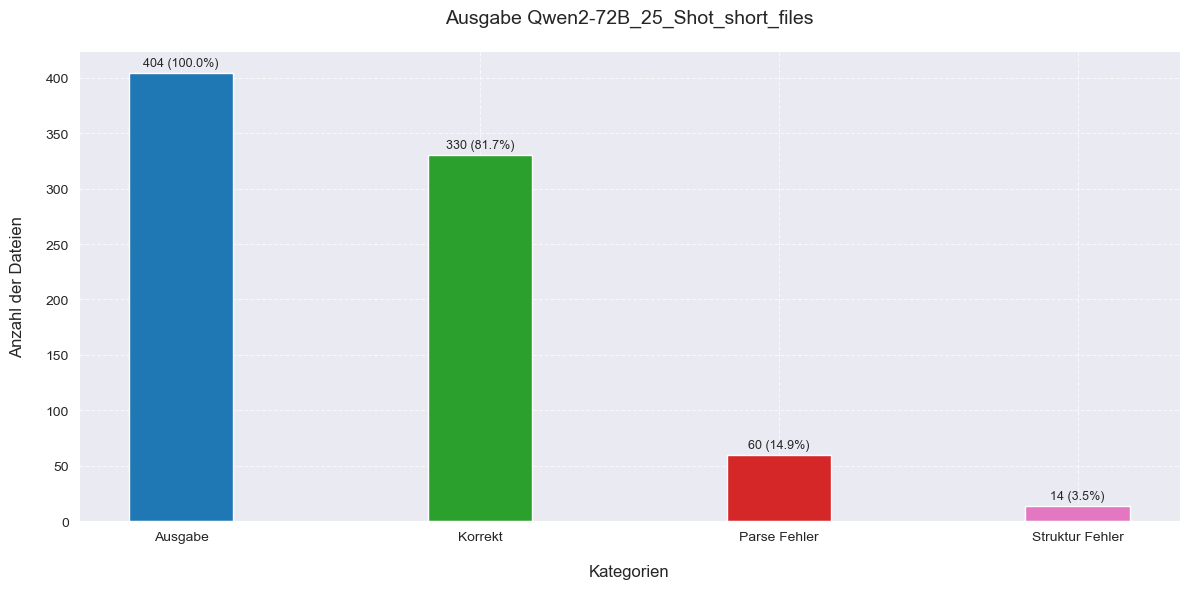

In [94]:
plot_file_counts(model_name, batch_name=batch_path)

In [95]:
def latex_file_counts_table(model_name, batch_name):
    model_folder_count, ready_folder_count, failure_folder_count, struct_failure_folder_count = count_files(model_name, batch_name)
    total_files = model_folder_count

    latex_table = f"""
\\begin{{table}}[!ht]
\\centering
\\begin{{tabular}}{{lrr}}
\\toprule
\\textbf{{Kategorie}} & \\textbf{{Anzahl}} & \\textbf{{Prozent}} \\\\
\\midrule
Ausgabe & {model_folder_count} & 100.0\\% \\\\
Korrekt & {ready_folder_count} & {(ready_folder_count / total_files * 100):.1f}\\% \\\\
Parse Fehler & {failure_folder_count} & {(failure_folder_count / total_files * 100):.1f}\\% \\\\
Struktur Fehler & {struct_failure_folder_count} & {(struct_failure_folder_count / total_files * 100):.1f}\\% \\\\
\\bottomrule
\\end{{tabular}}
\\caption{{Ausgabe {model_name}}}
\\label{{tab:file_counts_{model_name.replace(" ", "_")}}}
\\end{{table}}
    """

    return latex_table

# Beispielaufruf:
print(latex_file_counts_table(model_name, batch_name=batch_path))


\begin{table}[!ht]
\centering
\begin{tabular}{lrr}
\toprule
\textbf{Kategorie} & \textbf{Anzahl} & \textbf{Prozent} \\
\midrule
Ausgabe & 404 & 100.0\% \\
Korrekt & 330 & 81.7\% \\
Parse Fehler & 60 & 14.9\% \\
Struktur Fehler & 14 & 3.5\% \\
\bottomrule
\end{tabular}
\caption{Ausgabe Qwen2-72B_25_Shot_short_files}
\label{tab:file_counts_Qwen2-72B_25_Shot_short_files}
\end{table}
    


In [96]:
def plot_metrics_all_entitys(model_name, metrics, categories):
    metrics_to_plot = ['precision', 'recall', 'f1']
    metric_labels = {'precision': 'P', 'recall': 'R', 'f1': 'F1'}

    # Sortiere die Kategorien nach F1-Score absteigend
    categories_sorted = sorted(categories, key=lambda x: metrics[x]['f1'], reverse=True)

    fig, ax = plt.subplots(figsize=(20, 12))  # Vergrößere die Figur

    x = np.arange(len(categories_sorted) + 1)  # +1 für die Gesamtbalken
    bar_width = 0.25
    opacity = 0.8

    for i, metric in enumerate(metrics_to_plot):
        values = [metrics[category][metric] * 100 for category in categories_sorted]
        total_value = metrics['total'][metric] * 100
        values.append(total_value)  # Füge die Gesamtwerte hinzu
        bars = ax.bar(x + i*bar_width, values, bar_width, alpha=opacity, label=f'{metric_labels[metric]}')

        for j, v in enumerate(values):
            ax.text(x[j] + i*bar_width, v + 1, f'{v:.1f}', ha='center', va='bottom', fontsize=8, rotation=90)

    ax.set_xlabel('Kategorie', fontsize=12, labelpad=10)
    ax.set_ylabel('Score (%)', fontsize=12, labelpad=10)
    ax.set_title(f'Evaluation: {model_name}', fontsize=16, pad=20)
    ax.set_xticks(x + bar_width)
    categories_sorted.append('Gesamt')  # Füge die Beschriftung für die Gesamtwerte hinzu
    ax.set_xticklabels(categories_sorted, rotation=90, ha='right', fontsize=8)
    ax.legend(loc='upper right', fontsize=10)
    ax.set_ylim(0, 105)

    plt.tight_layout()
    plt.savefig(f'data/pics/evaluation_{model_name}_all_categories.png', dpi=300, bbox_inches='tight')
    plt.show()

In [97]:
def plot_heatmap(model_name, metrics, categories):
    # Erstelle eine DataFrame mit den Metriken
    data = {cat: [metrics[cat]['precision'], metrics[cat]['recall'], metrics[cat]['f1']] for cat in categories}
    df = pd.DataFrame(data, index=['Precision', 'Recall', 'F1']).T
    df_sorted = df.sort_values('F1', ascending=False)

    plt.figure(figsize=(15, len(categories) * 0.3))
    sns.heatmap(df_sorted, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Score'})
    plt.title(f'Metriken für {model_name}')
    plt.tight_layout()
    plt.savefig(f'data/pics/heatmap_{model_name}.png')
    plt.show()

In [98]:
#plot_heatmap(model_name, metrics, categories)

#### Model Performance

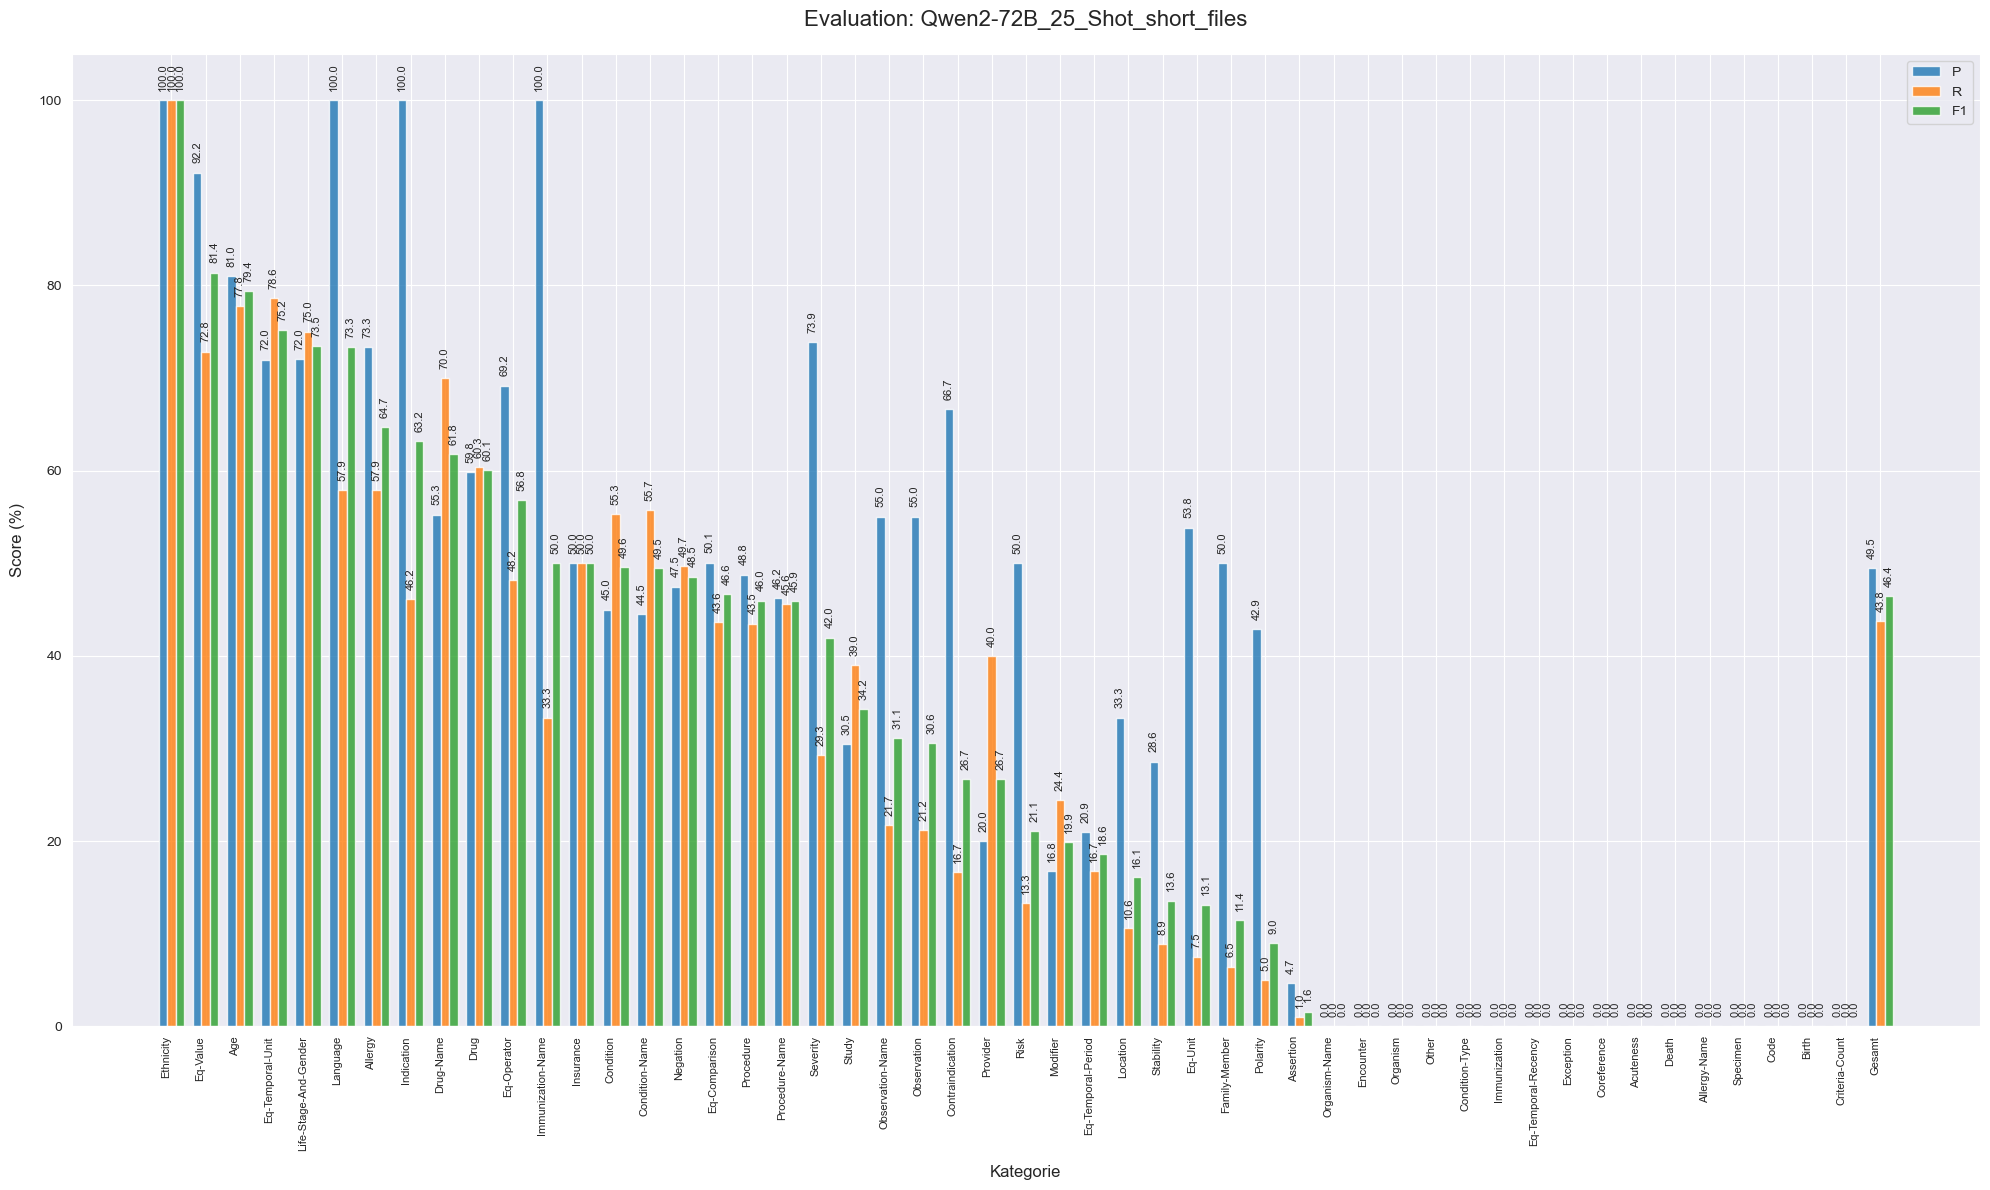

In [99]:
model_name = models[0]
plot_metrics_all_entitys(model_name, metrics, categories)

In [100]:
def generate_latex_table(model_name, metrics, categories):
    # Sortiere die Kategorien nach F1-Score absteigend
    categories_sorted = sorted(categories, key=lambda x: metrics[x]['f1'], reverse=True)

    # Beginne die LaTeX-Tabelle
    latex_table = "\\begin{table}[htbp]\n"
    latex_table += "\\centering\n"
    latex_table += "\\begin{tabular}{p{5cm}ccc}\n"  # Mehr Platz für die erste Spalte
    latex_table += "\\toprule\n"
    latex_table += "\\textbf{Kategorie} & \\textbf{Precision} & \\textbf{Recall} & \\textbf{F1-Score} \\\\\n"
    latex_table += "\\midrule\n"

    # Füge jede Kategorie mit ihren Metriken hinzu
    for category in categories_sorted:
        precision = metrics[category]['precision']
        recall = metrics[category]['recall']
        f1 = metrics[category]['f1']
        latex_table += f"{category} & {precision:.3f} & {recall:.3f} & {f1:.3f} \\\\\n"

    # Schließe die Tabelle
    latex_table += "\\bottomrule\n"
    latex_table += "\\end{tabular}\n"
    latex_table += "\\caption{Metriken für " + model_name + "}\n"  # Caption am Ende
    latex_table += "\\label{tab:metrics_" + model_name.lower().replace(" ", "_") + "}\n"
    latex_table += "\\end{table}"

    # Erstelle den 'latex' Ordner, falls er nicht existiert
    os.makedirs('latex', exist_ok=True)

    # Speichere die LaTeX-Tabelle in einer Datei im 'latex' Ordner
    file_path = f'data/latex/{model_name}_all_enitys.tex'
    with open(file_path, 'w', encoding='utf-8') as f:
        f.write(latex_table)

    return latex_table

In [101]:
generate_latex_table(model_name, metrics, categories)

'\\begin{table}[htbp]\n\\centering\n\\begin{tabular}{p{5cm}ccc}\n\\toprule\n\\textbf{Kategorie} & \\textbf{Precision} & \\textbf{Recall} & \\textbf{F1-Score} \\\\\n\\midrule\nEthnicity & 1.000 & 1.000 & 1.000 \\\\\nEq-Value & 0.922 & 0.728 & 0.814 \\\\\nAge & 0.810 & 0.778 & 0.794 \\\\\nEq-Temporal-Unit & 0.720 & 0.786 & 0.752 \\\\\nLife-Stage-And-Gender & 0.720 & 0.750 & 0.735 \\\\\nLanguage & 1.000 & 0.579 & 0.733 \\\\\nAllergy & 0.733 & 0.579 & 0.647 \\\\\nIndication & 1.000 & 0.462 & 0.632 \\\\\nDrug-Name & 0.553 & 0.700 & 0.618 \\\\\nDrug & 0.598 & 0.603 & 0.601 \\\\\nEq-Operator & 0.692 & 0.482 & 0.568 \\\\\nImmunization-Name & 1.000 & 0.333 & 0.500 \\\\\nInsurance & 0.500 & 0.500 & 0.500 \\\\\nCondition & 0.450 & 0.553 & 0.496 \\\\\nCondition-Name & 0.445 & 0.557 & 0.495 \\\\\nNegation & 0.475 & 0.497 & 0.485 \\\\\nEq-Comparison & 0.501 & 0.436 & 0.466 \\\\\nProcedure & 0.488 & 0.435 & 0.460 \\\\\nProcedure-Name & 0.463 & 0.456 & 0.459 \\\\\nSeverity & 0.739 & 0.293 & 0.420 \\\\

In [102]:
def generate_comparison_latex_table(model_name, metrics):
    def format_metrics(p, r, f1):
        return f"{p*100:.1f}/{r*100:.1f}/{f1*100:.1f}"

    latex_table = r"""
\begin{table}[htbp]
\centering
\begin{tabular}{llcc}
\toprule
\textbf{Category} & \textbf{Entity} & \textbf{SciBERT} & \textbf{""" + model_name + r"""} \\
\midrule
\multirow{6}{*}{Clinical} & Condition & 78.4/83.3/80.8 & """ + format_metrics(metrics['Condition']['precision'], metrics['Condition']['recall'], metrics['Condition']['f1']) + r""" \\
 & Contraindication & 100.0/96.6/98.3 & """ + format_metrics(metrics['Contraindication']['precision'], metrics['Contraindication']['recall'], metrics['Contraindication']['f1']) + r""" \\
 & Drug & 73.4/80.9/77.0 & """ + format_metrics(metrics['Drug']['precision'], metrics['Drug']['recall'], metrics['Drug']['f1']) + r""" \\
 & Encounter & 58.3/74.4/65.4 & """ + format_metrics(metrics['Encounter']['precision'], metrics['Encounter']['recall'], metrics['Encounter']['f1']) + r""" \\
 & Observation & 72.1/77.6/74.7 & """ + format_metrics(metrics['Observation']['precision'], metrics['Observation']['recall'], metrics['Observation']['f1']) + r""" \\
 & Procedure & 71.3/79.4/75.1 & """ + format_metrics(metrics['Procedure']['precision'], metrics['Procedure']['recall'], metrics['Procedure']['f1']) + r""" \\
\midrule
\multirow{5}{*}{Demographic} & Age & 99.1/98.3/98.7 & """ + format_metrics(metrics['Age']['precision'], metrics['Age']['recall'], metrics['Age']['f1']) + r""" \\
 & Birth & 100.0/62.5/76.9 & """ + format_metrics(metrics['Birth']['precision'], metrics['Birth']['recall'], metrics['Birth']['f1']) + r""" \\
 & Death & 100.0/20.0/33.3 & """ + format_metrics(metrics['Death']['precision'], metrics['Death']['recall'], metrics['Death']['f1']) + r""" \\
 & Family-Member & 44.9/61.1/51.7 & """ + format_metrics(metrics['Family-Member']['precision'], metrics['Family-Member']['recall'], metrics['Family-Member']['f1']) + r""" \\
 & Language & 96.6/93.5/95.0 & """ + format_metrics(metrics['Language']['precision'], metrics['Language']['recall'], metrics['Language']['f1']) + r""" \\
\midrule
Logical & Negation & 73.5/82.9/77.9 & """ + format_metrics(metrics['Negation']['precision'], metrics['Negation']['recall'], metrics['Negation']['f1']) + r""" \\
\midrule
\multirow{6}{*}{Qualifier} & Assertion & 62.1/65.8/63.9 & """ + format_metrics(metrics['Assertion']['precision'], metrics['Assertion']['recall'], metrics['Assertion']['f1']) + r""" \\
 & Modifier & 58.5/65.4/61.8 & """ + format_metrics(metrics['Modifier']['precision'], metrics['Modifier']['recall'], metrics['Modifier']['f1']) + r""" \\
 & Polarity & 81.4/79.5/80.4 & """ + format_metrics(metrics['Polarity']['precision'], metrics['Polarity']['recall'], metrics['Polarity']['f1']) + r""" \\
 & Risk & 95.4/91.3/93.3 & """ + format_metrics(metrics['Risk']['precision'], metrics['Risk']['recall'], metrics['Risk']['f1']) + r""" \\
 & Severity & 86.5/94.1/90.2 & """ + format_metrics(metrics['Severity']['precision'], metrics['Severity']['recall'], metrics['Severity']['f1']) + r""" \\
 & Stability & 75.3/84.7/79.7 & """ + format_metrics(metrics['Stability']['precision'], metrics['Stability']['recall'], metrics['Stability']['f1']) + r""" \\
\midrule
\multirow{6}{*}{Temporal and Comparative} & Eq-Comparison & 85.3/89.3/87.3 & """ + format_metrics(metrics['Eq-Comparison']['precision'], metrics['Eq-Comparison']['recall'], metrics['Eq-Comparison']['f1']) + r""" \\
 & Criteria-Count & 12.5/20.0/15.5 & """ + format_metrics(metrics['Criteria-Count']['precision'], metrics['Criteria-Count']['recall'], metrics['Criteria-Count']['f1']) + r""" \\
 & Eq-Temporal-Period & 82.6/86.3/84.4 & """ + format_metrics(metrics['Eq-Temporal-Period']['precision'], metrics['Eq-Temporal-Period']['recall'], metrics['Eq-Temporal-Period']['f1']) + r""" \\
 & Eq-Temporal-Recency & 50.0/66.6/57.1 & """ + format_metrics(metrics['Eq-Temporal-Recency']['precision'], metrics['Eq-Temporal-Recency']['recall'], metrics['Eq-Temporal-Recency']['f1']) + r""" \\
 & Eq-Temporal-Unit & 98.2/99.4/98.8 & """ + format_metrics(metrics['Eq-Temporal-Unit']['precision'], metrics['Eq-Temporal-Unit']['recall'], metrics['Eq-Temporal-Unit']['f1']) + r""" \\
 & Eq-Value & 96.4/97.1/96.7 & """ + format_metrics(metrics['Eq-Value']['precision'], metrics['Eq-Value']['recall'], metrics['Eq-Value']['f1']) + r""" \\
\midrule
Other & Location & 73.4/78.3/75.8 & """ + format_metrics(metrics['Location']['precision'], metrics['Location']['recall'], metrics['Location']['f1']) + r""" \\
\midrule
-- & Total & 79.0/83.7/81.3 & """ + format_metrics(metrics['total']['precision'], metrics['total']['recall'], metrics['total']['f1']) + r""" \\
\bottomrule
\end{tabular}
\caption{Leistungsvergleich der Metriken auf dem LCT Korpus: SciBERT vs """ + model_name + r""" (\%, Precision/Recall/F1). Die Gesamtauswertung umfasst 50 Entitätskategorien.}
\label{tab:metrics_comparison}
\end{table}
    """

    file_path =  f'data/latex/{model_name}_compare_entitys.tex'
    with open(file_path, 'w', encoding='utf-8') as f:
        f.write(latex_table)
    return latex_table

In [103]:
generate_comparison_latex_table(model_name, metrics)

'\n\\begin{table}[htbp]\n\\centering\n\\begin{tabular}{llcc}\n\\toprule\n\\textbf{Category} & \\textbf{Entity} & \\textbf{SciBERT} & \\textbf{Qwen2-72B_25_Shot_short_files} \\\\\n\\midrule\n\\multirow{6}{*}{Clinical} & Condition & 78.4/83.3/80.8 & 45.0/55.3/49.6 \\\\\n & Contraindication & 100.0/96.6/98.3 & 66.7/16.7/26.7 \\\\\n & Drug & 73.4/80.9/77.0 & 59.8/60.3/60.1 \\\\\n & Encounter & 58.3/74.4/65.4 & 0.0/0.0/0.0 \\\\\n & Observation & 72.1/77.6/74.7 & 55.0/21.2/30.6 \\\\\n & Procedure & 71.3/79.4/75.1 & 48.8/43.5/46.0 \\\\\n\\midrule\n\\multirow{5}{*}{Demographic} & Age & 99.1/98.3/98.7 & 81.0/77.8/79.4 \\\\\n & Birth & 100.0/62.5/76.9 & 0.0/0.0/0.0 \\\\\n & Death & 100.0/20.0/33.3 & 0.0/0.0/0.0 \\\\\n & Family-Member & 44.9/61.1/51.7 & 50.0/6.5/11.4 \\\\\n & Language & 96.6/93.5/95.0 & 100.0/57.9/73.3 \\\\\n\\midrule\nLogical & Negation & 73.5/82.9/77.9 & 47.5/49.7/48.5 \\\\\n\\midrule\n\\multirow{6}{*}{Qualifier} & Assertion & 62.1/65.8/63.9 & 4.7/1.0/1.6 \\\\\n & Modifier & 58

### Calculate Metrics for AND OR NOT

In [104]:
label_folder = "../input/lct_p1_half_with_and/" # '../input/lct_p1_half/'
raw_lct_text_folder = '../input/lct_txt_half'
model_output_folder = f'{batch_path}/model_output/' 

In [105]:
def extract_file_name(filename):
    pattern = r'NCT(\d+)_(inc|exc)'
    match = re.search(pattern, filename)
    if match:
        nct_number = 'NCT' + match.group(1)
        suffix = match.group(2)
        return f"{nct_number}_{suffix}"
    else:
        return None

def find_operator_words(text, operators):
    words = {op: [] for op in operators}
    word_list = text.split()
    for i, word in enumerate(word_list):
        if word in ["[AND]", "[OR]", "[NOT]", "[AND1]"]:
            operator = word[1:-1]
            if operator in operators:
                j = i - 1
                while j >= 0 and word_list[j] in ["[AND]", "[OR]", "[NOT]", "[AND1]"]:
                    j -= 1
                if j >= 0:
                    prev_word = re.sub(r'[^\w]', '', word_list[j])  # Remove punctuation
                    words[operator].append(prev_word)
    return words

def compare_operators(label_text, model_text, operator):
    label_operators = extract_operators(label_text) + ['AND1']
    model_operators = extract_operators(model_text)

    label_words_dict = find_operator_words(label_text, label_operators)
    model_words_dict = find_operator_words(model_text, model_operators)

    tp = 0
    fp = 0
    fn = 0
    label_count = 0
    model_word_count = 0

    if operator in ['AND', 'AND1']:
        label_words_and = label_words_dict.get('AND', [])
        label_words_and1 = label_words_dict.get('AND1', [])
        model_words = model_words_dict.get('AND', [])
        model_word_count = len(model_words)
        print("Label AND:", label_words_and)
        print("Label AND1:", label_words_and1)
        print("Model  AND:", model_words)
        for word in model_words:
            if operator == 'AND':
                if word in label_words_and:
                    tp += 1
                elif word not in label_words_and1:
                    fp += 1
            elif operator == 'AND1':
                if word in label_words_and1:
                    tp += 1
                elif word not in label_words_and:
                    fp += 1

        if operator == 'AND':
            fn = sum(1 for word in label_words_and if word not in model_words)
            label_count = len(label_words_and)
        else:  # AND1
            fn = sum(1 for word in label_words_and1 if word not in model_words)
            label_count = len(label_words_and1)
    else:  # OR und NOT
        label_words = label_words_dict.get(operator, [])
        model_words = model_words_dict.get(operator, [])

        tp = sum(1 for word in label_words if word in model_words)
        fp = sum(1 for word in model_words if word not in label_words)
        fn = sum(1 for word in label_words if word not in model_words)
        label_count = len(label_words)
        model_word_count = len(model_words)
    if operator == "AND" or operator == "AND1":
        print(operator)
        print(f"TP: {tp}, FP: {fp}, FN: {fn}, Label count: {label_count}, Model count: {model_word_count}")
    return tp, fp, fn, label_count, model_word_count

def evaluate_models(label_folder, model_folder, model_name, raw_lct_text_folder):
    operators = ['AND', 'AND1', 'OR', 'NOT']
    metrics = {op: {'tp': 0, 'fp': 0, 'fn': 0, 'label_count': 0, 'model_count': 0, 'correct_count': 0, 'correct_ncts': set(), 'low_tp_ncts': set()} for op in operators}
    processed_label_files = 0
    total_missing_words = Counter()
    total_missing_pct = 0.0
    model_results = []
    label_files = {f.split('.')[0]: os.path.join(label_folder, f) for f in os.listdir(label_folder) if f.endswith('.txt')}

    for model_file in os.listdir(model_folder):
        if model_file.endswith('.txt'):
            identifier = extract_file_name(model_file)
            print(identifier)
            if identifier in label_files:
                label_file_path = label_files[identifier]
                model_file_path = os.path.join(model_folder, model_file)
                raw_lct_text_path = os.path.join(raw_lct_text_folder, f'{identifier}.txt')

                if os.path.exists(label_file_path):
                    processed_label_files += 1
                    label_text = read_file(label_file_path)
                    model_text = read_file(model_file_path)
                    raw_lct_text = read_file(raw_lct_text_path)
                    model_raw_text = clean_criteria_text(model_text)
                    missing_words, missing_percentage = compare_texts(raw_lct_text, model_raw_text)
                    total_missing_pct += missing_percentage
                    total_missing_words.update(missing_words)

                    model_data = {'nct_number': identifier}

                    for op in operators:
                        tp, fp, fn, label_count, model_count = compare_operators(label_text, model_text, op)

                        metrics[op]['tp'] += tp
                        metrics[op]['fp'] += fp
                        metrics[op]['fn'] += fn
                        metrics[op]['label_count'] += label_count
                        metrics[op]['model_count'] += model_count

                        metrics[op]['correct_count'] += tp

                        model_data[f'{op}_tp'] = tp
                        model_data[f'{op}_fp'] = fp
                        model_data[f'{op}_fn'] = fn
                        model_data[f'{op}_label_count'] = label_count
                        model_data[f'{op}_model_count'] = model_count

                        if tp > 0:
                            metrics[op]['correct_ncts'].add(identifier)
                        if tp == 0 and fn > 4:
                            metrics[op]['low_tp_ncts'].add(identifier)

                    model_results.append(model_data)

    results = calculate_aggregated_results(metrics, processed_label_files, total_missing_pct, operators)
    return results


In [106]:
all_metrics = {}
for model in models:
    model_folder = os.path.join(model_output_folder, model, 'processed_output')
    metrics = evaluate_models(label_folder, model_folder, model, raw_lct_text_folder)
    all_metrics[model] = metrics

NCT03860194_exc
Label AND: []
Label AND1: ['months', 'resident', 'failure', 'failure', 'mellitus']
Model  AND: ['months', 'resident', 'failure', 'failure', 'mellitus']
AND
TP: 0, FP: 0, FN: 0, Label count: 0, Model count: 5
Label AND: []
Label AND1: ['months', 'resident', 'failure', 'failure', 'mellitus']
Model  AND: ['months', 'resident', 'failure', 'failure', 'mellitus']
AND1
TP: 5, FP: 0, FN: 0, Label count: 5, Model count: 5
NCT03860194_inc
Label AND: []
Label AND1: ['years', 'Japan']
Model  AND: ['years', 'women', 'ms']
AND
TP: 0, FP: 2, FN: 0, Label count: 0, Model count: 3
Label AND: []
Label AND1: ['years', 'Japan']
Model  AND: ['years', 'women', 'ms']
AND1
TP: 1, FP: 2, FN: 1, Label count: 2, Model count: 3
NCT03860415_inc
Label AND: []
Label AND1: ['by', 'antibiogram', 'sachets', 'Swedish', 'Sweden']
Model  AND: ['by', 'antibiogram', 'sachets', 'Swedish', 'Sweden']
AND
TP: 0, FP: 0, FN: 0, Label count: 0, Model count: 5
Label AND: []
Label AND1: ['by', 'antibiogram', 'sachets

In [107]:
all_metrics

{'Qwen2-72B_25_Shot_short_files': {'AND': {'precision': 17.5531914893617,
   'recall': 27.049180327868854,
   'f1': 21.29032258064516,
   'accuracy': 27.049180327868854,
   'total_label': 120,
   'total_model': 1007,
   'correct_count': 33,
   'low_tp_ncts': ['NCT03865953_inc']},
  'AND1': {'precision': 84.19979612640162,
   'recall': 81.4595660749507,
   'f1': 82.80701754385964,
   'accuracy': 81.4595660749507,
   'total_label': 1005,
   'total_model': 1007,
   'correct_count': 826,
   'low_tp_ncts': ['NCT03927781_exc', 'NCT03921437_exc']},
  'OR': {'precision': 56.896551724137936,
   'recall': 14.072494669509595,
   'f1': 22.564102564102566,
   'accuracy': 14.072494669509595,
   'total_label': 469,
   'total_model': 113,
   'correct_count': 66,
   'low_tp_ncts': ['NCT03920345_exc',
    'NCT03864133_exc',
    'NCT03861312_exc',
    'NCT03920579_exc',
    'NCT03925454_exc',
    'NCT03864289_exc',
    'NCT03865953_inc',
    'NCT03865524_exc',
    'NCT03921437_exc',
    'NCT03925675_exc'

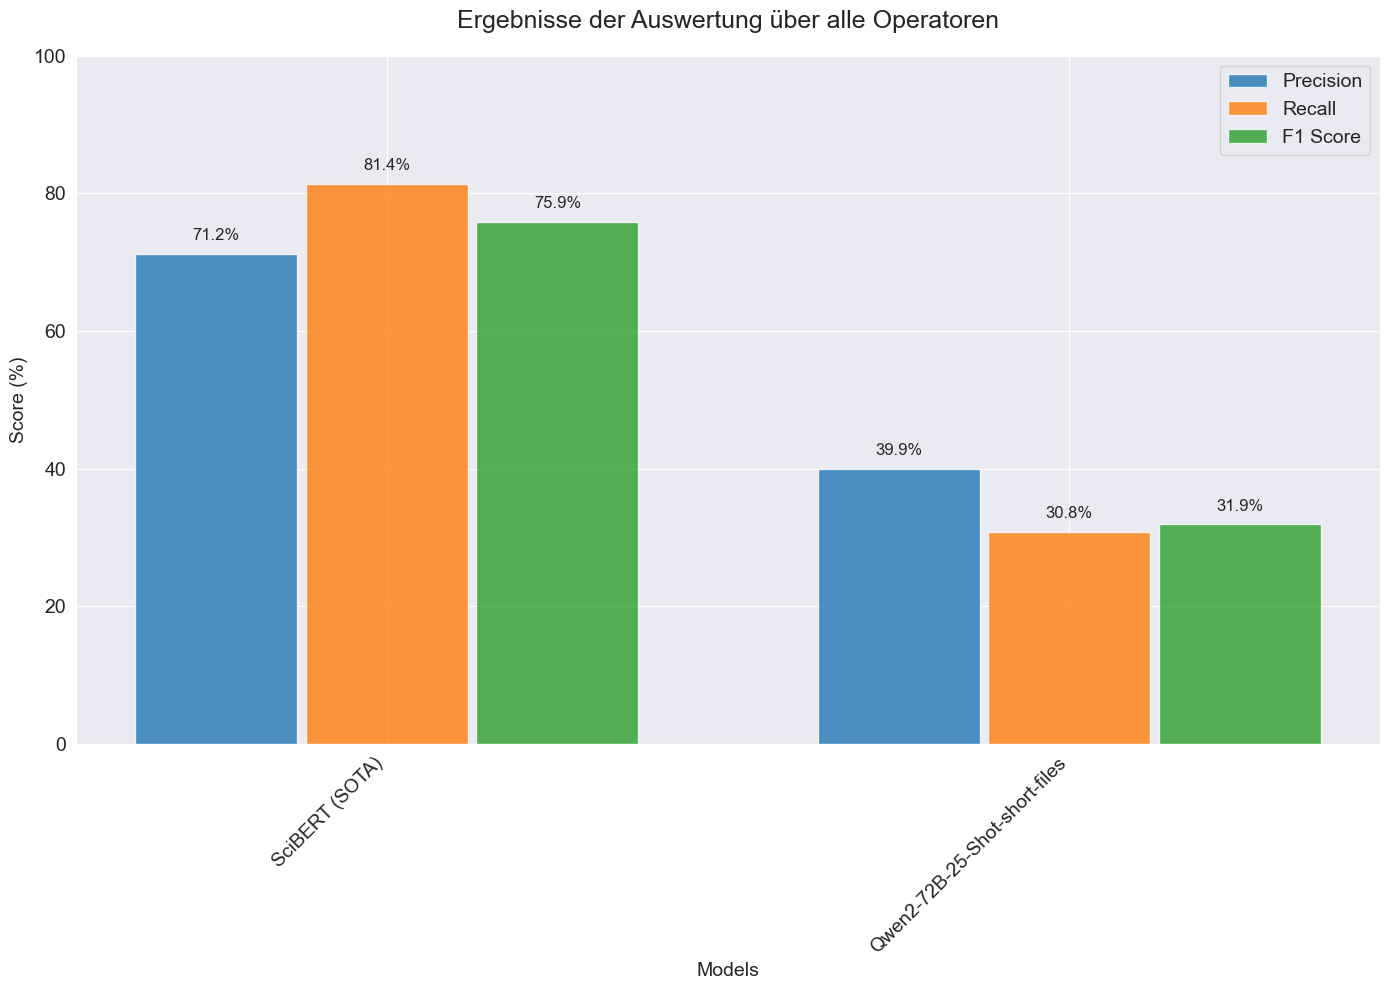

In [108]:
plot_avg_metrics(all_metrics)

In [109]:
def plot_operator_metrics(all_metrics):
    operators = ['AND', 'AND1', 'OR', 'NOT']
    metrics_to_plot = ['precision', 'recall', 'f1']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Farben für Precision, Recall, F1

    sota_metrics = {
        'SciBERT': {
            'AND': {'precision': 54.1, 'recall': 60.0, 'f1': 56.9},
            'AND1': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}, 
            'NOT': {'precision': 74.3, 'recall': 91.0, 'f1': 81.8},
            'OR': {'precision': 85.1, 'recall': 93.2, 'f1': 89.0}
        }
    }

    for i, op in enumerate(operators):
        plt.figure(figsize=(12, 8))  # Größere Figur

        model_names = ['SOTA'] + [e.replace('_p4_ep10_p1', '') for e in list(all_metrics.keys())]
        metric_values = {metric: [] for metric in metrics_to_plot}

        # SOTA-Metriken hinzufügen
        for metric in metrics_to_plot:
            metric_values[metric].append(sota_metrics['SciBERT'][op][metric])

        # Andere Modellmetriken hinzufügen
        for model, model_metrics in all_metrics.items():
            for metric in metrics_to_plot:
                metric_values[metric].append(model_metrics[op][metric])

        x = np.arange(len(model_names))
        bar_width = 0.25
        opacity = 0.8

        for j, metric in enumerate(metrics_to_plot):
            plt.bar(x + j * bar_width, metric_values[metric], bar_width,
                    alpha=opacity, label=metric.capitalize(), color=colors[j])

        plt.xlabel('Models', fontsize=14, labelpad=10)
        plt.ylabel('Score (%)', fontsize=14, labelpad=10)
        plt.title(f'Evaluation: {op}', fontsize=18, pad=20)  # Mehr Abstand nach dem Titel
        plt.xticks(x + bar_width, model_names, rotation=45, ha='right', fontsize=12)
        plt.ylim(0, 110)  # Erhöhung des y-Limits für mehr Platz oben
        plt.legend(fontsize=12, loc='upper center', ncol=3)  # Legende unter dem Plot
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        # Werte über den Balken anzeigen
        for j, metric in enumerate(metrics_to_plot):
            for k, v in enumerate(metric_values[metric]):
                plt.text(k + j * bar_width, v + 2, f'{v:.1f}%',
                         ha='center', va='bottom', fontsize=10)

        plt.tight_layout()
        plt.savefig(f'data/pics/operator_metrics_{op}.png', bbox_inches='tight')
        plt.show()

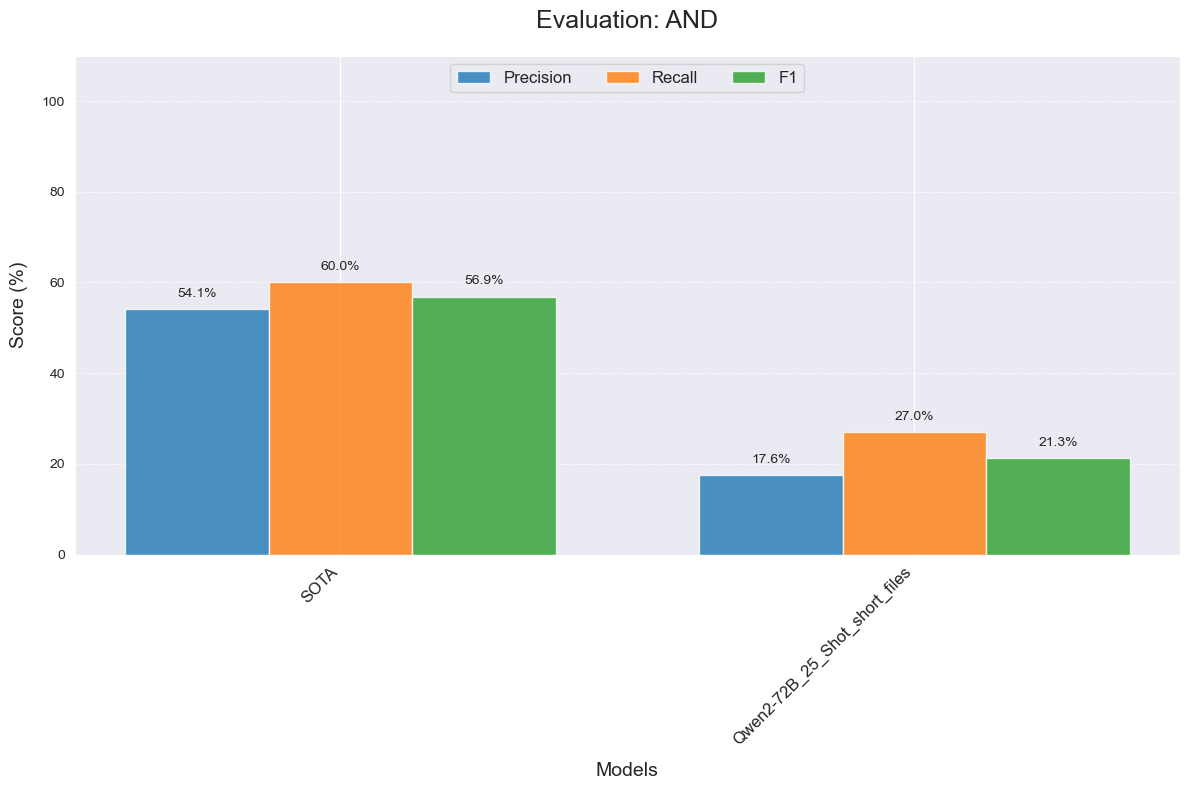

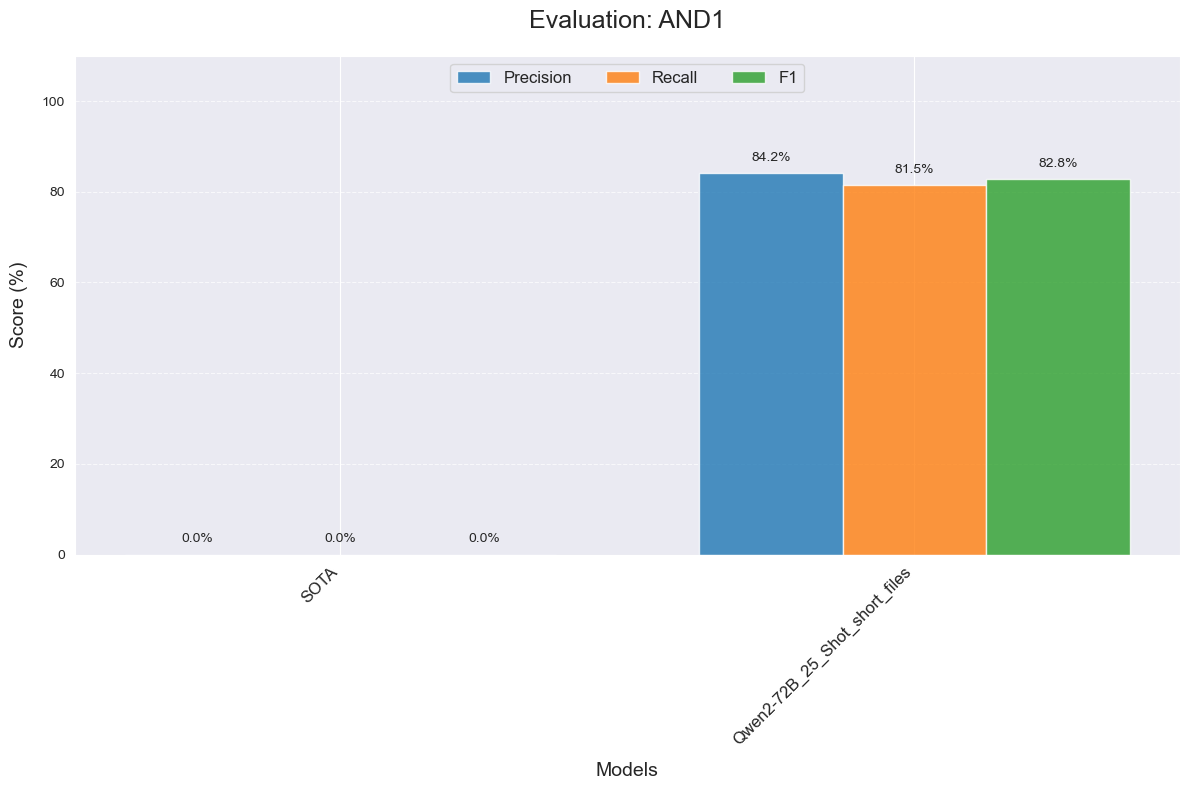

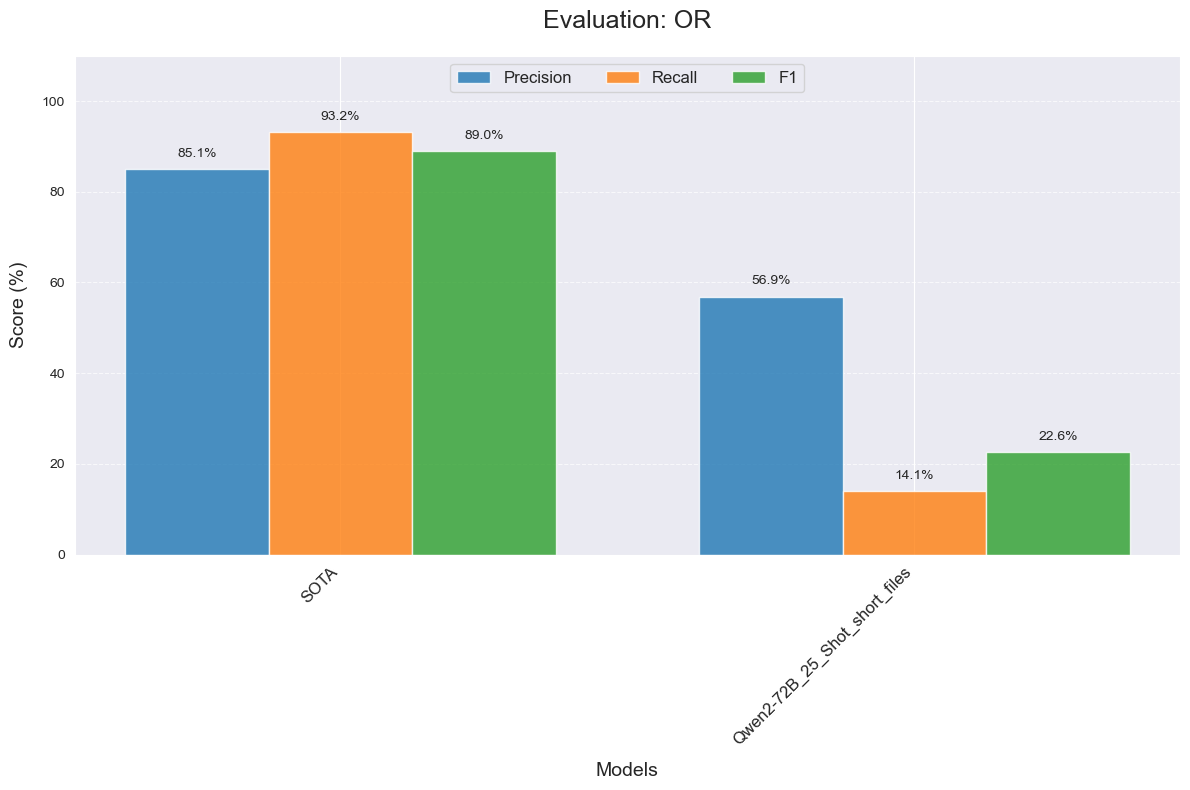

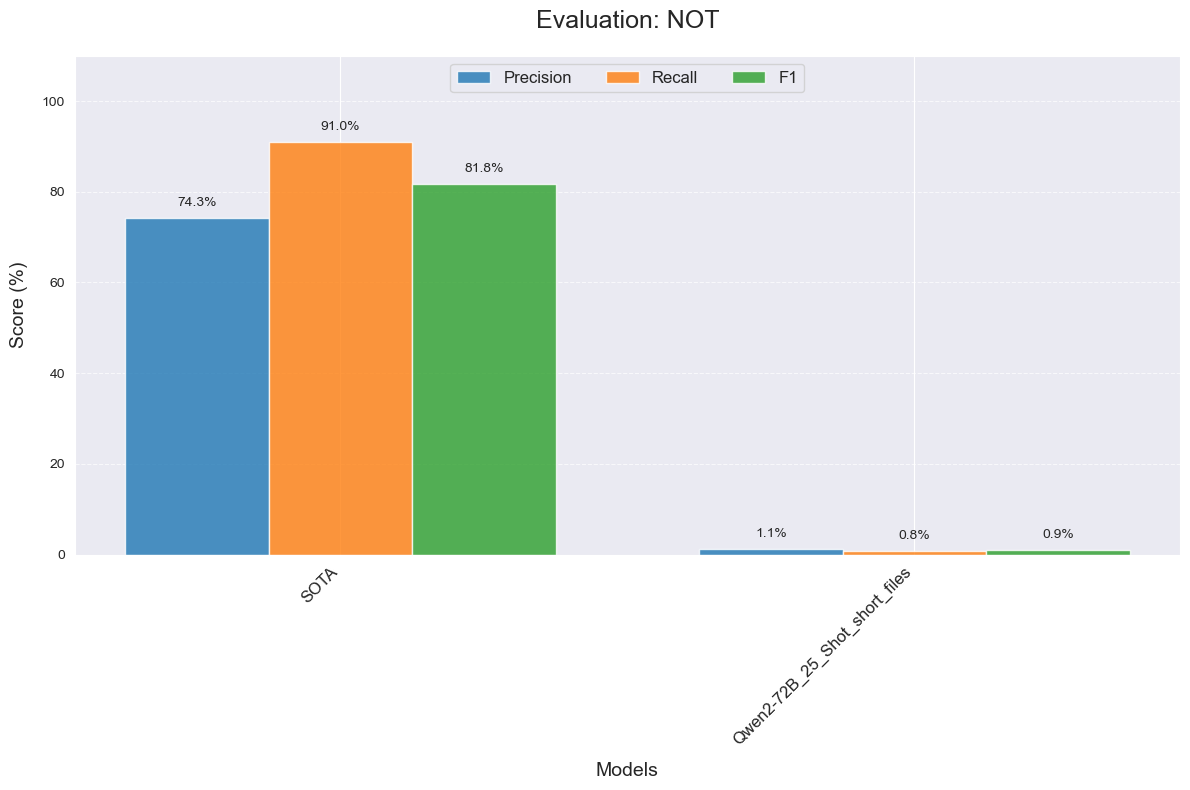

In [110]:
plot_operator_metrics(all_metrics)

In [111]:
def latex_operator_metrics_table(all_metrics):
    operators = ['AND', 'AND1', 'OR', 'NOT']
    metrics_to_plot = ['precision', 'recall', 'f1']

    sota_metrics = {
        'SciBERT': {
            'AND': {'precision': 54.1, 'recall': 60.0, 'f1': 56.9},
            'AND1': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0},
            'NOT': {'precision': 74.3, 'recall': 91.0, 'f1': 81.8},
            'OR': {'precision': 85.1, 'recall': 93.2, 'f1': 89.0}
        }
    }

    latex_table = r"\begin{table}[!ht]" + "\n"
    latex_table += r"\centering" + "\n"
    latex_table += r"\small" + "\n"
    latex_table += r"\begin{tabular}{llrrrrr}" + "\n"  # Eine weitere Spalte für den Durchschnittswert
    latex_table += r"\toprule" + "\n"
    latex_table += r"\textbf{Model} & \textbf{Metrik} & \multicolumn{4}{c}{\textbf{Operator}} & \textbf{Durchschnitt} \\" + "\n"
    latex_table += r"\cmidrule(lr){3-6}" + "\n"
    latex_table += r"& & AND & AND1 & OR & NOT & \\" + "\n"
    latex_table += r"\midrule" + "\n"

    model_names = ['SOTA'] + list(all_metrics.keys())

    for model in model_names:
        model_display = 'SOTA\n(SciBERT)' if model == 'SOTA' else 'Llama3 70B\n(Fine-Tuned)'
        for i, metric in enumerate(metrics_to_plot):
            metric_display = 'Precision' if metric == 'precision' else 'Recall' if metric == 'recall' else 'F1-Score'
            latex_table += f"{model_display if i == 0 else ''} & {metric_display}"
            values = []
            for op in operators:
                if model == 'SOTA':
                    value = sota_metrics['SciBERT'][op][metric]
                else:
                    value = all_metrics[model][op][metric]
                latex_table += f" & {value:.1f}"
                if op != 'AND1':  # AND1 nicht in die Durchschnittsberechnung einbeziehen
                    values.append(value)
            average_value = sum(values) / len(values)  # Durchschnitt berechnen ohne AND1
            latex_table += f" & {average_value:.1f}"  # Durchschnittswert hinzufügen
            latex_table += r" \\" + "\n"
        if model != model_names[-1]:
            latex_table += r"\midrule" + "\n"

    latex_table += r"\bottomrule" + "\n"
    latex_table += r"\end{tabular}" + "\n"
    latex_table += r"\caption{Vergleich der Operatormetriken für SOTA (SciBERT) und Llama3 70B (Fine-Tuned)}" + "\n"
    latex_table += r"\label{tab:operator_metrics}" + "\n"
    latex_table += r"\end{table}"

    return latex_table

# Beispielaufruf:
print(latex_operator_metrics_table(all_metrics))


\begin{table}[!ht]
\centering
\small
\begin{tabular}{llrrrrr}
\toprule
\textbf{Model} & \textbf{Metrik} & \multicolumn{4}{c}{\textbf{Operator}} & \textbf{Durchschnitt} \\
\cmidrule(lr){3-6}
& & AND & AND1 & OR & NOT & \\
\midrule
SOTA
(SciBERT) & Precision & 54.1 & 0.0 & 85.1 & 74.3 & 71.2 \\
 & Recall & 60.0 & 0.0 & 93.2 & 91.0 & 81.4 \\
 & F1-Score & 56.9 & 0.0 & 89.0 & 81.8 & 75.9 \\
\midrule
Llama3 70B
(Fine-Tuned) & Precision & 17.6 & 84.2 & 56.9 & 1.1 & 25.2 \\
 & Recall & 27.0 & 81.5 & 14.1 & 0.8 & 14.0 \\
 & F1-Score & 21.3 & 82.8 & 22.6 & 0.9 & 14.9 \\
\bottomrule
\end{tabular}
\caption{Vergleich der Operatormetriken für SOTA (SciBERT) und Llama3 70B (Fine-Tuned)}
\label{tab:operator_metrics}
\end{table}
